In [4]:
import pandas as pd

# 1. Define the correct column names (The 'Headers')
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

# 2. Load and Clean: Handle spaces and apply the headers
df = pd.read_csv('house Prediction Data Set.csv', sep='\s+', names=column_names)

# 3. Final Polish: Drop any rows that have empty (NaN) values
df = df.dropna()

# Check your clean table
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


House Price Model R2 Score: 0.3708


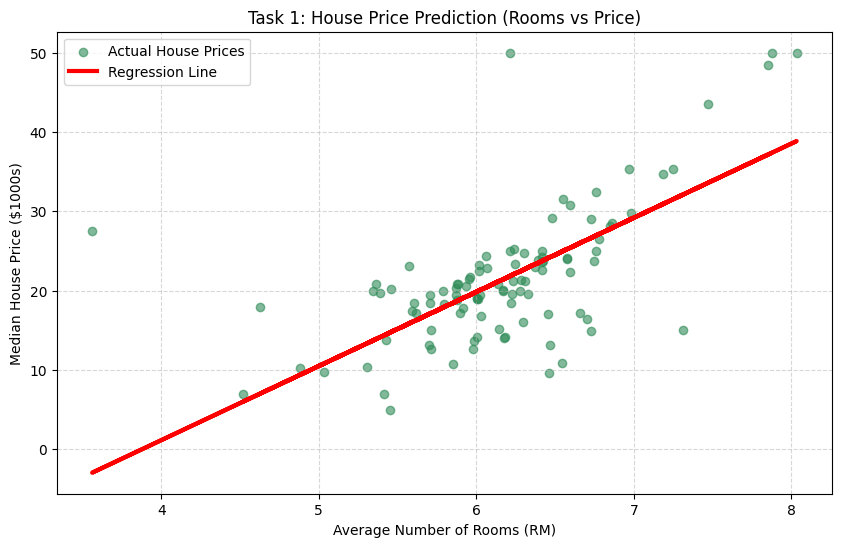

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Step 1: Loading the data
# Note: This specific file is space-separated, so we use sep='\s+'
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df = pd.read_csv('house Prediction Data Set.csv', sep='\s+', names=column_names)

# Step 2: Selecting Features (X) and Target (y)
# We use 'RM' (Number of Rooms) to predict 'MEDV' (Price)
X = df[['RM']] 
y = df['MEDV']

# Step 3: Splitting into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Training the Linear Regression model
house_model = LinearRegression()
house_model.fit(X_train, y_train)

# Step 5: Testing the model
predictions = house_model.predict(X_test)
accuracy = r2_score(y_test, predictions)
print(f"House Price Model R2 Score: {accuracy:.4f}")

# Step 6: Plotting the results (Perfect for the screen recording)
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='seagreen', alpha=0.6, label='Actual House Prices')
plt.plot(X_test, predictions, color='red', linewidth=3, label='Regression Line')

plt.title('Task 1: House Price Prediction (Rooms vs Price)')
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('Median House Price ($1000s)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()